In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
price_dfs, trade_dfs = [], []
for day in [1, 2, 3]:
    p = pd.read_csv(f'prices_round_4_day_{day}.csv', sep=';')
    t = pd.read_csv(f'trades_round_4_day_{day}.csv', sep=';')
    p['global_ts'] = p['timestamp'] + (day - 1) * 1_000_000
    t['global_ts'] = t['timestamp'] + (day - 1) * 1_000_000
    price_dfs.append(p)
    trade_dfs.append(t)

prices = pd.concat(price_dfs, ignore_index=True)
trades = pd.concat(trade_dfs, ignore_index=True)

ASSETS = ['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK']
COLORS = {'VELVETFRUIT_EXTRACT': '#2196F3', 'HYDROGEL_PACK': '#FF5722'}

In [21]:
# Spot price series
spot_px = (
    prices[prices['product'].isin(ASSETS)]
    [['global_ts', 'product', 'mid_price', 'bid_price_1', 'ask_price_1']]
    .copy()
)

pivot = spot_px.pivot_table(index='global_ts', columns='product', values='mid_price', aggfunc='first')
pivot_z = (pivot - pivot.mean()) / pivot.std()

In [ ]:
# Classify trades: Lee-Ready (bid/ask first, then tick rule)
spot_tr = trades[trades['symbol'].isin(ASSETS)].copy()

price_ref = (
    spot_px[['global_ts', 'product', 'mid_price', 'bid_price_1', 'ask_price_1']]
    .rename(columns={'product': 'symbol'})
)
spot_tr = spot_tr.merge(price_ref, on=['global_ts', 'symbol'], how='left')

def classify(group):
    g = group.sort_values('global_ts').copy()
    dirs, prev_p, last_d = [], None, 'buy'
    for _, r in g.iterrows():
        p, bid, ask = r['price'], r['bid_price_1'], r['ask_price_1']
        if pd.notna(ask) and p >= ask:
            d = 'buy'
        elif pd.notna(bid) and p <= bid:
            d = 'sell'
        elif prev_p is not None:
            d = 'buy' if p > prev_p else ('sell' if p < prev_p else last_d)
        else:
            d = 'buy'
        dirs.append(d)
        prev_p = p
        last_d = d
    g['direction'] = dirs
    return g

spot_tr = pd.concat(
    [classify(grp) for _, grp in spot_tr.groupby('symbol')],
    ignore_index=True,
)


KeyError: 'symbol'

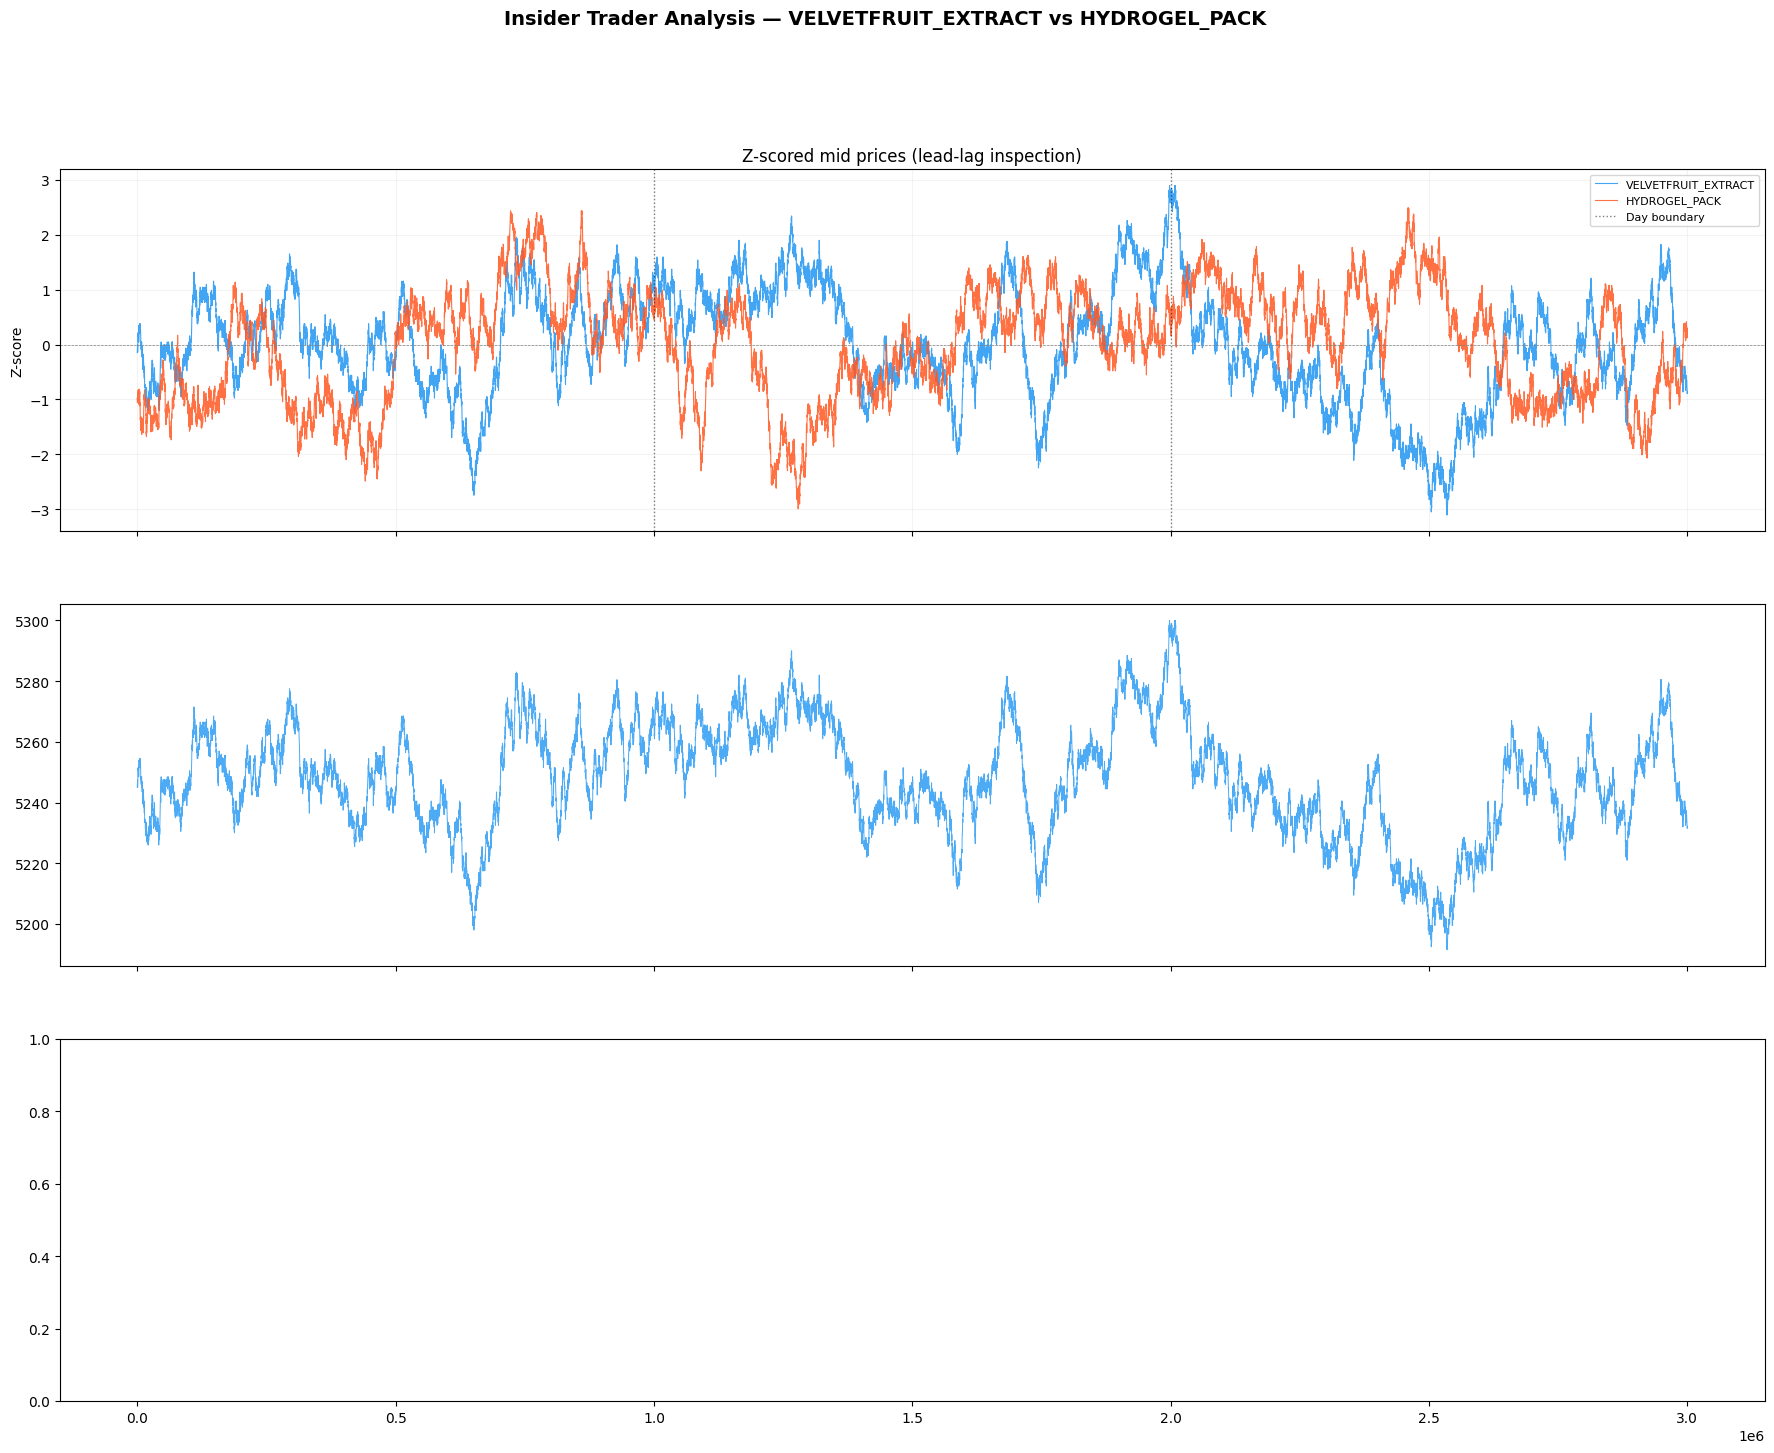

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(22, 16), sharex=True)
fig.suptitle('Insider Trader Analysis — VELVETFRUIT_EXTRACT vs HYDROGEL_PACK', fontsize=14, fontweight='bold')

day_starts = [1_000_000, 2_000_000]

# Top: Z-scored lead-lag
ax0 = axes[0]
for col in ASSETS:
    if col in pivot_z.columns:
        ax0.plot(pivot_z.index, pivot_z[col], label=col, color=COLORS[col], linewidth=0.8, alpha=0.85)
ax0.axhline(0, color='gray', linewidth=0.5, ls='--')
for i, d in enumerate(day_starts):
    ax0.axvline(d, color='k', linewidth=1, ls=':', alpha=0.5, label='Day boundary' if i == 0 else None)
ax0.set_ylabel('Z-score')
ax0.set_title('Z-scored mid prices (lead-lag inspection)')
ax0.legend(fontsize=8, loc='upper right')
ax0.grid(True, alpha=0.15)

# Per-asset: price + trade arrows
for i, asset in enumerate(ASSETS):
    ax = axes[i + 1]

    px = spot_px[spot_px['product'] == asset].sort_values('global_ts')
    ax.plot(px['global_ts'], px['mid_price'],
            color=COLORS[asset], linewidth=0.7, alpha=0.8, label='Mid price')

    for dr, mk, col, lbl in [
        ('buy',  '^', '#4CAF50', 'Taker buy'),
        ('sell', 'v', '#F44336', 'Taker sell'),
    ]:
        sub = spot_tr[(spot_tr['symbol'] == asset) & (spot_tr['direction'] == dr)]
        ax.scatter(
            sub['global_ts'], sub['price'],
            marker=mk, c=col, s=50, zorder=5,
            label=f'{lbl} ({len(sub)})',
            edgecolors='k', linewidths=0.3,
        )

    for d in day_starts:
        ax.axvline(d, color='k', linewidth=1, ls=':', alpha=0.5)

    ax.set_ylabel('Price')
    ax.set_title(asset)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.15)

axes[-1].set_xlabel('Global timestamp  (day offset = 1,000,000)')
plt.tight_layout()
plt.savefig('insider_trader_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Trade summary table
summary = (
    spot_tr[['global_ts', 'symbol', 'buyer', 'seller', 'price', 'quantity', 'direction', 'mid_price']]
    .assign(price_vs_mid=lambda df: (df['price'] - df['mid_price']).round(2))
    .sort_values('global_ts')
    .reset_index(drop=True)
)

print(f'Total spot trades: {len(summary)}')
print()
print('Buy/sell count per participant (as buyer):')
print(summary.groupby('buyer')['direction'].value_counts().unstack(fill_value=0))
print()
print('Buy/sell count per participant (as seller):')
print(summary.groupby('seller')['direction'].value_counts().unstack(fill_value=0))

Total spot trades: 2403

Buy/sell count per participant (as buyer):
direction  buy  sell
buyer               
Mark 01      0   260
Mark 14      0   812
Mark 22      6    30
Mark 38    515     0
Mark 49      1    16
Mark 55    598     0
Mark 67    164     1

Buy/sell count per participant (as seller):
direction  buy  sell
seller              
Mark 01    244     0
Mark 14    838     0
Mark 22     98    11
Mark 38      0   507
Mark 49    104     1
Mark 55      0   600


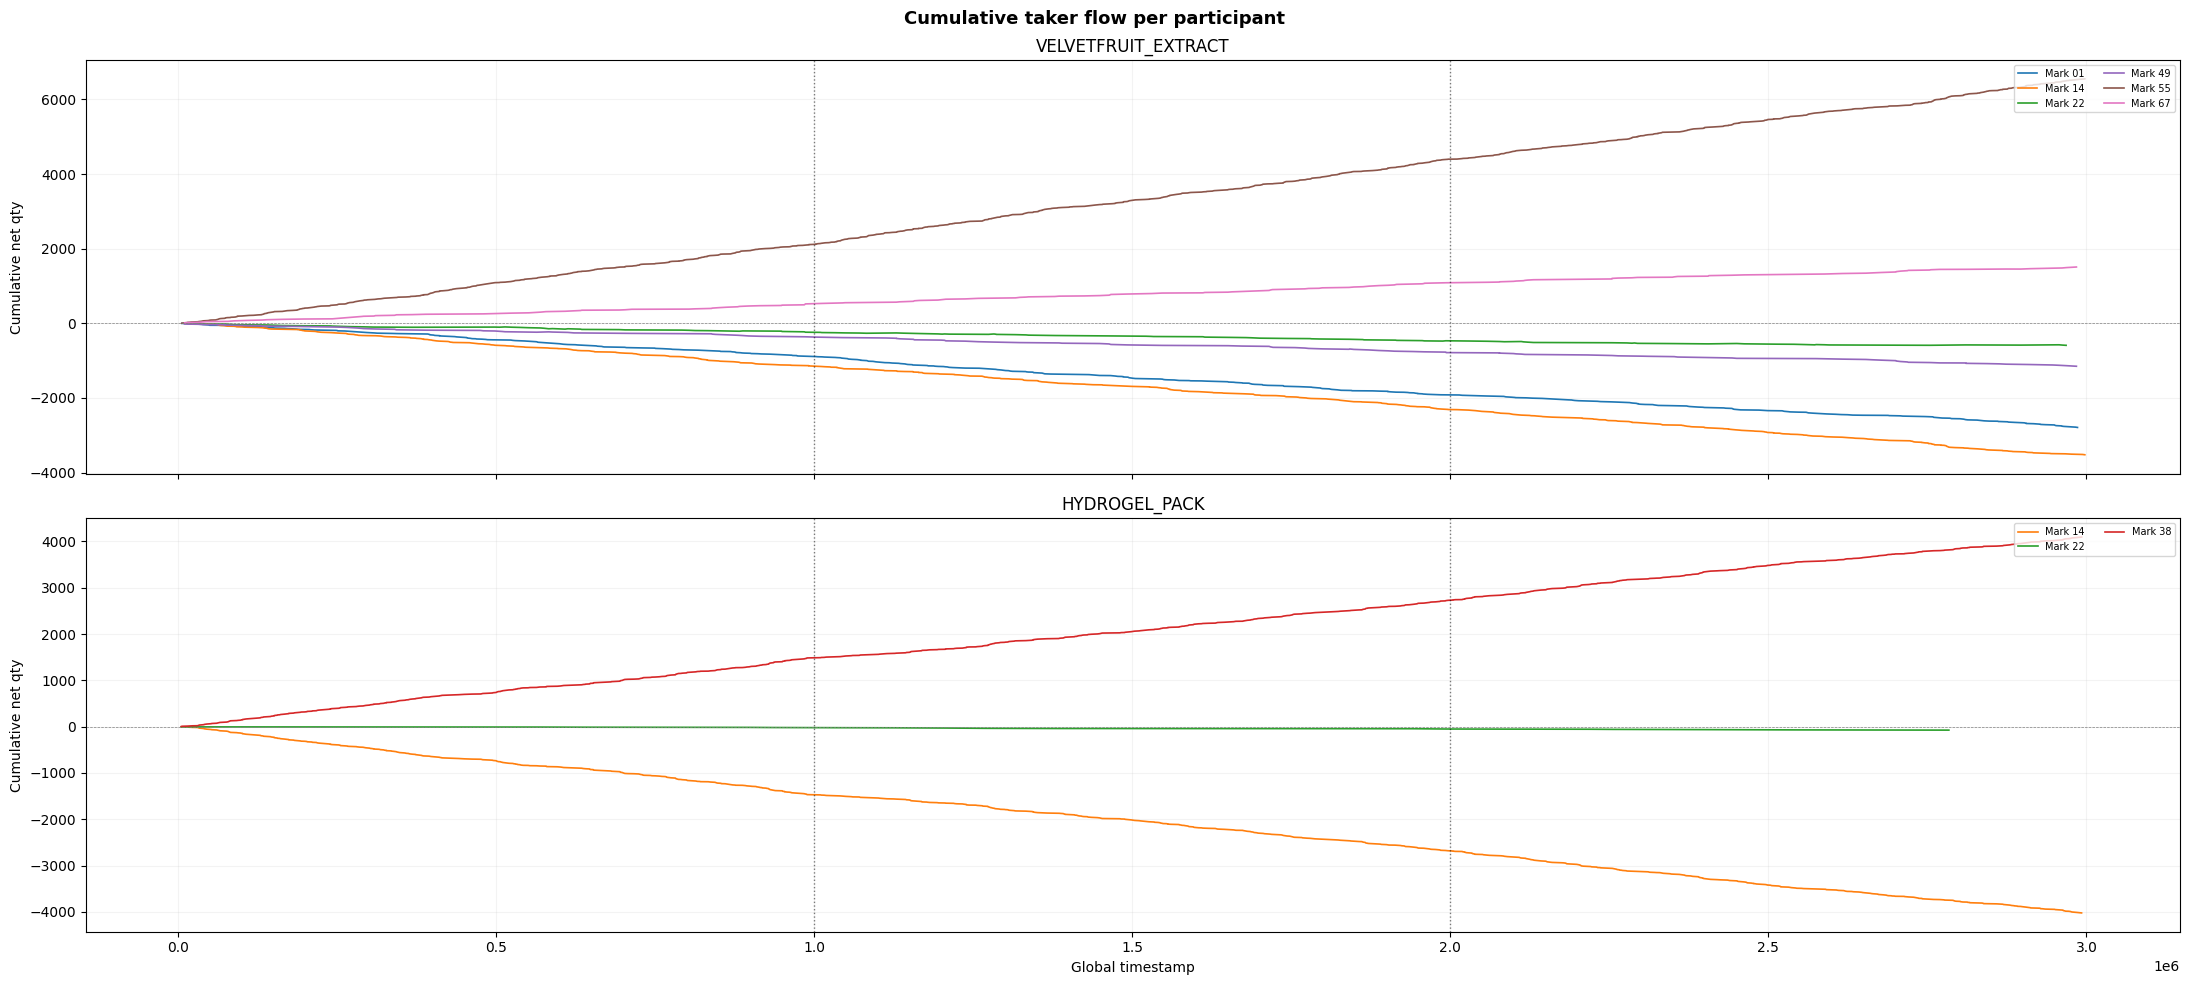

In [ ]:
# Cumulative net taker flow per participant — front-running shows up as consistent directionality
participants = sorted(set(summary['buyer']) | set(summary['seller']))
cmap = plt.get_cmap('tab10')
p_colors = {p: cmap(i % 10) for i, p in enumerate(participants)}

fig, axes = plt.subplots(len(ASSETS), 1, figsize=(22, 10), sharex=True)
fig.suptitle('Cumulative taker flow per participant', fontsize=13, fontweight='bold')

for ax, asset in zip(axes, ASSETS):
    asset_tr = summary[summary['symbol'] == asset].copy()
    sign = asset_tr['direction'].map({'buy': 1, 'sell': -1})

    for participant in participants:
        as_buyer  = asset_tr[asset_tr['buyer']  == participant].copy()
        as_seller = asset_tr[asset_tr['seller'] == participant].copy()
        as_buyer['net']  =  as_buyer['quantity'] * as_buyer['direction'].map({'buy': 1, 'sell': -1})
        as_seller['net'] = -as_seller['quantity'] * as_seller['direction'].map({'buy': 1, 'sell': -1})
        flow = pd.concat([as_buyer[['global_ts', 'net']], as_seller[['global_ts', 'net']]])
        if flow.empty:
            continue
        flow = flow.sort_values('global_ts')
        flow['cum'] = flow['net'].cumsum()
        ax.plot(flow['global_ts'], flow['cum'], label=participant,
                color=p_colors[participant], linewidth=1.2)

    for d in day_starts:
        ax.axvline(d, color='k', linewidth=1, ls=':', alpha=0.5)
    ax.axhline(0, color='gray', linewidth=0.5, ls='--')
    ax.set_title(asset)
    ax.set_ylabel('Cumulative net qty')
    ax.legend(fontsize=7, loc='upper right', ncol=2)
    ax.grid(True, alpha=0.15)

axes[-1].set_xlabel('Global timestamp')
plt.tight_layout()
plt.savefig('insider_trader_flow.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Price lookup series indexed by global_ts
px_by_asset = {}
for asset in ASSETS:
    s = spot_px[spot_px['product'] == asset].set_index('global_ts')['mid_price'].sort_index()
    px_by_asset[asset] = s

# Who crossed the spread
spot_tr['taker'] = np.where(spot_tr['direction'] == 'buy', spot_tr['buyer'], spot_tr['seller'])

HORIZONS = [1_000, 5_000, 10_000, 50_000, 100_000]

for h in HORIZONS:
    fwd = []
    for _, r in spot_tr.iterrows():
        s = px_by_asset[r.symbol]
        t = r.global_ts + h
        fwd.append(float(s.asof(t)) if t <= s.index[-1] else float('nan'))
    spot_tr[f'fwd_{h}'] = fwd
    spot_tr[f'pnl_{h}'] = np.where(
        spot_tr['direction'] == 'buy',
        (spot_tr[f'fwd_{h}'] - spot_tr['price']) * spot_tr['quantity'],
        (spot_tr['price'] - spot_tr[f'fwd_{h}']) * spot_tr['quantity'],
    )

print('Cumulative taker PnL per participant:')
print(spot_tr.groupby('taker')[[f'pnl_{h}' for h in HORIZONS]].sum().round(1).to_string())


In [ ]:
participants = sorted(spot_tr['taker'].unique())
H = 10_000  # 100 ticks

fig, axes = plt.subplots(len(ASSETS), len(participants), figsize=(22, 8), sharey='row')
fig.suptitle(f'Per-trade taker PnL at +{H // 100} tick horizon  (bars = per trade, navy line = cumulative)',
             fontsize=12, fontweight='bold')

for col_idx, participant in enumerate(participants):
    for row_idx, asset in enumerate(ASSETS):
        ax = axes[row_idx, col_idx]
        df = spot_tr[(spot_tr['taker'] == participant) & (spot_tr['symbol'] == asset)].sort_values('global_ts')

        if df.empty:
            ax.axis('off')
            continue

        pnl = df[f'pnl_{H}'].values
        colors = ['#4CAF50' if x > 0 else '#F44336' for x in pnl]
        ax.bar(range(len(df)), pnl, color=colors, width=0.8, alpha=0.85)
        ax.axhline(0, color='k', linewidth=0.5)

        ax2 = ax.twinx()
        ax2.plot(range(len(df)), np.cumsum(pnl), color='navy', linewidth=1.5)
        ax2.tick_params(axis='y', labelsize=5)

        if row_idx == 0:
            ax.set_title(participant, fontsize=8)
        if col_idx == 0:
            ax.set_ylabel(asset.replace('VELVETFRUIT_EXTRACT', 'VEV').replace('HYDROGEL_PACK', 'HYD'), fontsize=8)
        ax.set_xlabel(f'n={len(df)}  Σ={np.nansum(pnl):.0f}', fontsize=6)
        ax.tick_params(axis='both', labelsize=5)

plt.tight_layout()
plt.savefig('pnl_grid.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
m67 = spot_tr[spot_tr['taker'] == 'Mark 67'].sort_values('global_ts')
FWD = 30_000  # 300 ticks

fig, axes = plt.subplots(len(ASSETS), 1, figsize=(22, 12))
fig.suptitle('Mark 67 — Forward price path (300 ticks) after each buy\n'
             'Green = profitable exit, Red = loss', fontsize=13, fontweight='bold')

for ax, asset in zip(axes, ASSETS):
    px_full = spot_px[spot_px['product'] == asset].sort_values('global_ts')
    px_s = px_by_asset[asset]

    ax.plot(px_full['global_ts'], px_full['mid_price'],
            color=COLORS[asset], linewidth=0.6, alpha=0.3, zorder=1, label='Mid price')

    m67_asset = m67[m67['symbol'] == asset]
    wins = losses = 0
    for _, trade in m67_asset.iterrows():
        ts, entry = trade['global_ts'], trade['price']
        end_ts = min(ts + FWD, px_s.index[-1])
        fwd_path = px_s.loc[ts:end_ts]
        profitable = float(fwd_path.iloc[-1]) > entry
        c = '#2E7D32' if profitable else '#C62828'
        ax.plot(fwd_path.index, fwd_path.values, color=c, linewidth=1.1, alpha=0.65, zorder=2)
        ax.scatter([ts], [entry], color=c, s=55, zorder=5, marker='^', edgecolors='k', linewidths=0.4)
        wins += profitable; losses += (not profitable)

    for d in day_starts:
        ax.axvline(d, color='k', linewidth=1, ls=':', alpha=0.4)
    ax.set_title(f'{asset}  |  Mark 67: {len(m67_asset)} buys  —  {wins} profitable (green), {losses} at loss (red)', fontsize=10)
    ax.set_ylabel('Price')
    ax.grid(True, alpha=0.12)

axes[-1].set_xlabel('Global timestamp  (day offset = 1,000,000)')
plt.tight_layout()
plt.savefig('mark67_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
LAGS = np.arange(-5_000, 51_000, 1_000)  # -50 to +500 ticks relative to trade

def avg_pct_response(trades):
    """Average direction-aligned % return at each lag (positive = moved in taker's favor)."""
    paths = []
    for _, r in trades.iterrows():
        s = px_by_asset[r.symbol]
        sign = 1 if r.direction == 'buy' else -1
        path = []
        for lag in LAGS:
            t = r.global_ts + lag
            if t < s.index[0] or t > s.index[-1]:
                path.append(float('nan'))
            else:
                path.append(sign * (float(s.asof(t)) - r.price) / r.price * 100)
        paths.append(path)
    return np.nanmean(paths, axis=0) if paths else np.full(len(LAGS), float('nan'))

participants = sorted(spot_tr['taker'].unique())
lags_ticks = LAGS / 100

fig, axes = plt.subplots(len(participants), 1, figsize=(16, 3.8 * len(participants)), sharex=True)
fig.suptitle('Event study: avg direction-aligned % return after taker trade\n'
             '(positive = price moved in taker\'s favor; flat = uninformed, trending up = informed)',
             fontsize=12, fontweight='bold')

for ax, participant in zip(axes, participants):
    trades = spot_tr[spot_tr['taker'] == participant]

    for asset in ASSETS:
        asset_trades = trades[trades['symbol'] == asset]
        if asset_trades.empty:
            continue
        resp = avg_pct_response(asset_trades)
        label = asset.replace('VELVETFRUIT_EXTRACT', 'VEV').replace('HYDROGEL_PACK', 'HYD')
        ax.plot(lags_ticks, resp, label=f'{label} (n={len(asset_trades)})',
                color=COLORS[asset], linewidth=1.5)

    resp_all = avg_pct_response(trades)
    ax.plot(lags_ticks, resp_all, label=f'Combined (n={len(trades)})',
            color='black', linewidth=1.8, ls='--')

    ax.axvline(0, color='k', linewidth=1, ls='--', alpha=0.4)
    ax.axhline(0, color='gray', linewidth=0.7)
    ax.set_title(participant, fontsize=10, fontweight='bold')
    ax.set_ylabel('Avg % return')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.12)

axes[-1].set_xlabel('Ticks relative to trade  (1 tick = 100 ts, 0 = trade time)')
plt.tight_layout()
plt.savefig('event_study.png', dpi=150, bbox_inches='tight')
plt.show()
